In [22]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
from easydict import EasyDict
import jax
import jax.numpy as jnp
from src.maenv.soccer import Soccer
from src.maenv.physics import CircleCollider, BoxCollider
import src.algorithms.MAPPO as MAPPO
from flax import nnx
import tensorflow_probability.substrates.jax as tfp
from collections import namedtuple
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import pygame


tfd = tfp.distributions
tfb = tfp.bijectors

config = EasyDict()
config.dt = 0.2
config.percent = 0.5
config.slop = 0.01
config.restitution = 0.8
config.state_dim = 12
config.action_dim = 10
config.batch_size = 256
config.episode_length = 1000
config.sync_period = 100
config.n_agents = 2
config.embed_dim = 64
config.layer_dim = 512
config.tau = 0.005
config.gamma = 0.99
config.lr = 3e-4
config.seed = 0

config.ppo_epochs = 10
config.clip_ratio = 0.05
config.entropy_coef = 0.0001


config.lamda = 0.95
config.n_env = 100
config.clip_value = 100000.0

pygame 2.6.1 (SDL 2.28.4, Python 3.10.12)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [3]:
soccer = Soccer(config)
v_reset = jax.vmap(soccer.reset)
v_step = jax.vmap(soccer.step, in_axes=(0, 0, 0))


In [5]:


def sample_action(policy, states, key):
    logits = policy(states)
    sample = tfd.Categorical(logits = logits).sample(seed = key)
    log_probs = tfd.Categorical(logits = logits).log_prob(sample)
    return sample, log_probs


left_team_state = MAPPO.init_train_state(config)
right_team_state = MAPPO.init_train_state(config)


NetworkState = namedtuple('NetworkState', ['graphdef', 'state'])
TrainState = namedtuple('TrainState', ['pi1_state', 'pi2_state', 'value_state', 'key'])
Model = namedtuple('Model', ['network', 'optimizer'])

rollout_info = namedtuple('rollout_info', ['obs', 'reward', 'done', 'log_pi1', 'log_pi2', 'log_pi3', 'log_pi4', 'a1', 'a2', 'a3', 'a4', 'left_values', 'right_values'])

def get_model(state: NetworkState) -> Model:
    network, optimizer = nnx.merge(state.graphdef, state.state)
    return network, optimizer


In [6]:
def rollout(left_team_state, right_team_state, key):
        
    pi1, pi1_optimizer = get_model(left_team_state.pi1_state)
    pi2, pi2_optimizer = get_model(left_team_state.pi2_state)
    pi3, pi3_optimizer = get_model(right_team_state.pi1_state)
    pi4, pi4_optimizer = get_model(right_team_state.pi2_state)
    left_value, left_value_optimizer = get_model(left_team_state.value_state)
    right_value, right_value_optimizer = get_model(right_team_state.value_state)

    def rollout_(carry, _):
        (env_state, obs, key) = carry
        key1, key2, key3, key4, env_reset_key, key = jax.random.split(key, 6)
        

        a1, log_pi1 = sample_action(pi1, obs['agent_0'], key1)
        a2, log_pi2 = sample_action(pi2, obs['agent_0'], key2)
        a3, log_pi3 = sample_action(pi3, obs['agent_2'], key3)
        a4, log_pi4 = sample_action(pi4, obs['agent_2'], key4)

        next_obs, next_state, reward, done, info = v_step(jax.random.split(key, config.n_env), env_state, {
            'agent_0': a1[:, None],
            'agent_1': a2[:, None],
            'agent_2': a3[:, None],
            'agent_3': a4[:, None]
        })

        init_obs, init_state = v_reset(jax.random.split(env_reset_key, config.n_env))

        is_reset = done | (info['timestep'] > config.episode_length)
        next_obs = jax.tree.map(lambda x, y : jnp.where(is_reset, x, y), init_obs, next_obs)
        next_state_ = jax.tree.map(lambda x, y : jnp.where(is_reset, x, y), init_state, next_state)


        return (next_state_, next_obs, key), (env_state, obs, reward, done, log_pi1, log_pi2, log_pi3, log_pi4, a1, a2, a3, a4)
    
    obs, state = v_reset(jax.random.split(key, config.n_env))
    _, (env_state, obs, reward, done, log_pi1, log_pi2, log_pi3, log_pi4, a1, a2, a3, a4) = jax.lax.scan(rollout_, (state, obs, key), None, config.episode_length)
    left_values = left_value(obs['agent_0'])
    right_values = right_value(obs['agent_2'])
    return rollout_info(obs, reward, done, log_pi1, log_pi2, log_pi3, log_pi4, a1, a2, a3, a4, left_values, right_values)

In [7]:
def train_body(carry, _):
    left_team_state, right_team_state, key = carry
    
    rollout_key, next_key = jax.random.split(key, 2)
    rollout_info = rollout(left_team_state, right_team_state, rollout_key)

    left_reward = rollout_info.reward['agent_0'] + rollout_info.reward['agent_1']
    right_reward = rollout_info.reward['agent_2'] + rollout_info.reward['agent_3']
    
    def calculate_gae(carry, xs):
        last_gae, v_t1, returns = carry
        reward, done, v = xs
        delta = reward + config.gamma * v_t1 - v
        last_gae = delta + config.gamma * config.lamda * last_gae
        returns = reward + config.gamma * returns
        return (last_gae * (1-done), v * (1-done), returns * (1-done)), (last_gae, returns)

    def get_gae(common_reward, done, left_values):
        _, outputs = jax.lax.scan(calculate_gae, (jnp.array([0.0]), jnp.array([0.0]), jnp.array([0.0])), (common_reward[::-1], jnp.roll(done[::-1], -1), left_values[::-1]))
        gae, _ = outputs
        gae = gae[::-1]
        return gae, gae + left_values
    # common_reward [max_step, n_env, 1]
    # common_reward [max_step, 1]
    left_gae, left_returns = jax.vmap(get_gae, in_axes=(1, 1, 1))(left_reward, rollout_info.done, rollout_info.left_values)
    right_gae, right_returns = jax.vmap(get_gae, in_axes=(1, 1, 1))(right_reward, rollout_info.done, rollout_info.right_values)
    left_gae = left_gae.transpose(1, 0, 2)
    left_returns = left_returns.transpose(1, 0, 2)
    right_gae = right_gae.transpose(1, 0, 2)
    right_returns = right_returns.transpose(1, 0, 2)

    n_batch = left_gae.shape[0] * left_gae.shape[1]

    left_batch = MAPPO.Batch(
        observation = rollout_info.obs['agent_0'].reshape(n_batch, -1),
        reward = left_reward.reshape(n_batch, -1),
        done = rollout_info.done.reshape(n_batch, -1),
        log_pi1 = rollout_info.log_pi1.reshape(n_batch, -1),
        log_pi2 = rollout_info.log_pi2.reshape(n_batch, -1),
        a1 = rollout_info.a1.reshape(n_batch, -1),
        a2 = rollout_info.a2.reshape(n_batch, -1),
        advantages = left_gae.reshape(n_batch, -1),
        returns = left_returns.reshape(n_batch, -1),
        values = rollout_info.left_values.reshape(n_batch, -1)
    )
    
    right_batch = MAPPO.Batch(
        observation = rollout_info.obs['agent_2'].reshape(n_batch, -1),
        reward = right_reward.reshape(n_batch, -1),
        done = rollout_info.done.reshape(n_batch, -1),
        log_pi1 = rollout_info.log_pi3.reshape(n_batch, -1),
        log_pi2 = rollout_info.log_pi4.reshape(n_batch, -1),
        a1 = rollout_info.a3.reshape(n_batch, -1),
        a2 = rollout_info.a4.reshape(n_batch, -1),
        advantages = right_gae.reshape(n_batch, -1),
        returns = right_returns.reshape(n_batch, -1),
        values = rollout_info.right_values.reshape(n_batch, -1)
    )
    
    def mappo_train_body(carry, _):
        left_team_state, right_team_state, = carry
        left_team_state, (left_v_loss, left_policy_loss, left_reward_sum) = MAPPO.train_step(config, left_team_state, left_batch)
        right_team_state, (right_v_loss, right_policy_loss, right_reward_sum) = MAPPO.train_step(config, right_team_state, right_batch)
        return (left_team_state, right_team_state), (left_v_loss.mean(), left_policy_loss.mean(), left_reward_sum, right_v_loss.mean(), right_policy_loss.mean(), right_reward_sum)

    (left_team_state, right_team_state), (left_v_loss, left_policy_loss, left_reward_sum, right_v_loss, right_policy_loss, right_reward_sum) = jax.lax.scan(mappo_train_body, (left_team_state, right_team_state), None, config.ppo_epochs)
    
    return (left_team_state, right_team_state, next_key), (left_v_loss.mean(), left_policy_loss.mean(), left_reward_sum, right_v_loss.mean(), right_policy_loss.mean(), right_reward_sum)

In [8]:
carry = (left_team_state, right_team_state, jax.random.key(config.seed))

In [9]:
carry, (left_v_loss, left_policy_loss, left_reward_sum, right_v_loss, right_policy_loss, right_reward_sum) = jax.lax.scan(train_body, carry, None, 100)

2025-06-12 10:28:23.594202: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.


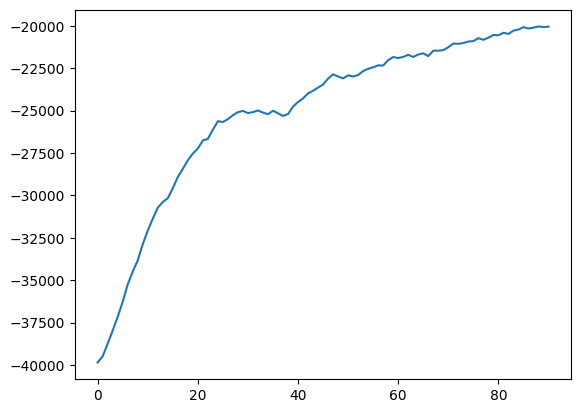

In [10]:
import matplotlib.pyplot as plt
window_size = 10 
moving_avg = jnp.convolve(left_reward_sum.mean(axis=-1), jnp.ones(window_size)/window_size, mode='valid')

plt.title('Moving Average of Return')
plt.plot(moving_avg)
plt.title('Value Loss')
plt.plot(left_v_loss)

In [14]:
left_team_state, right_team_state = carry[0], carry[1]

pi1, pi1_optimizer = get_model(left_team_state.pi1_state)
pi2, pi2_optimizer = get_model(left_team_state.pi2_state)
value, value_optimizer = get_model(left_team_state.value_state)

pi3, pi3_optimizer = get_model(right_team_state.pi1_state)
pi4, pi4_optimizer = get_model(right_team_state.pi2_state)
value3, value3_optimizer = get_model(right_team_state.value_state)

_, pi1_state = nnx.split(pi1)
_, pi2_state = nnx.split(pi2)
_, pi3_state = nnx.split(pi3)
_, pi4_state = nnx.split(pi4)
_, value_state = nnx.split(value)
_, value3_state = nnx.split(value3)


In [17]:
key = jax.random.key(config.seed)
        
pi1, pi1_optimizer = get_model(left_team_state.pi1_state)
pi2, pi2_optimizer = get_model(left_team_state.pi2_state)
value, value_optimizer = get_model(left_team_state.value_state)

pi3, pi3_optimizer = get_model(right_team_state.pi1_state)
pi4, pi4_optimizer = get_model(right_team_state.pi2_state)
value3, value3_optimizer = get_model(right_team_state.value_state)


def rollout_(carry, _):
    (env_state, obs, key) = carry
    key1, key2, key3, key4, env_reset_key, key = jax.random.split(key, 6)
    
    def get_action(obs, key):
        return jax.random.randint(key, (obs.shape[0], ), 0, 2), jnp.array(0.0)
    a1, log_pi1 = sample_action(pi1, obs['agent_0'], key1)
    a2, log_pi2 = sample_action(pi2, obs['agent_0'], key2)
    a3, log_pi3 = sample_action(pi3, obs['agent_2'], key3)
    a4, log_pi4 = sample_action(pi4, obs['agent_2'], key4)

    next_obs, next_state, reward, done, info = v_step(jax.random.split(key, config.n_env), env_state, {
        'agent_0': a1[:, None],
        'agent_1': a2[:, None],
        'agent_2': a3[:, None],
        'agent_3': a4[:, None]
    })

    init_obs, init_state = v_reset(jax.random.split(env_reset_key, config.n_env))

    is_reset = done | (info['timestep'] > config.episode_length)
    next_obs = jax.tree.map(lambda x, y : jnp.where(is_reset, x, y), init_obs, next_obs)
    next_state_ = jax.tree.map(lambda x, y : jnp.where(is_reset, x, y), init_state, next_state)

    return (next_state_, next_obs, key), (env_state, obs, reward, is_reset, log_pi1, log_pi2, a1, a2)

# Reset environment and get initial observation and state
obs, state = v_reset(jax.random.split(key, config.n_env))
(env_state, _, key), (env_state, obs, reward, done, log_pi1, log_pi2, a1, a2) = jax.lax.scan(
    rollout_, (state, obs, key), None, config.episode_length
)

# Animation creation and display

def visualize_frame(objects, ax, frame_num=None):
    """Visualize all objects in the current frame."""
    ax.clear()
    ax.set_xlim(-10, 10)
    ax.set_ylim(-10, 10)
    ax.set_aspect('equal')
    
    # Display current frame number and score
    title_text = f"Frame: {frame_num}"
    ax.set_title(title_text)
    
    for obj in objects.values():
        if hasattr(obj, 'collider'):
            if isinstance(obj.collider, CircleCollider):
                circle = plt.Circle(
                    (obj.transform.position[0], obj.transform.position[1]),
                    obj.collider.radius,
                    color=np.array(obj.texture.color),
                    fill=True
                )
                ax.add_patch(circle)
            elif isinstance(obj.collider, BoxCollider):
                rectangle = patches.Rectangle(
                    (obj.transform.position[0] - obj.collider.width / 2, obj.transform.position[1] - obj.collider.height / 2),
                    obj.collider.width,
                    obj.collider.height,
                    color=np.array(obj.texture.color),
                    fill=True
                )
                ax.add_patch(rectangle)
        
    return ax.patches

def create_animation(history, interval=50, save_gif=False, filename='simulation.gif', frame_skip=1):
    """Create an animation of the simulation results."""
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Apply frame skipping
    total_frames = len(history['ball'].transform.position)
    frames_to_show = range(0, total_frames, frame_skip)
    
    def update(frame_idx):
        frame = frames_to_show[frame_idx]
        return visualize_frame(jax.tree.map(lambda x: x[frame], history), ax, frame_num=frame)
    
    ani = FuncAnimation(
        fig, 
        update, 
        frames=len(frames_to_show),
        interval=interval,
        blit=True
    )
    
    # Save as GIF if requested
    if save_gif:
        ani.save(filename, writer='pillow', fps=1000//interval)
        print(f"Animation saved as {filename}")
    
    plt.close()  # Prevent static figure display
    return HTML(ani.to_jshtml())

def save_animation_as_gif(history, Box, filename='simulation.gif', interval=50, frame_skip=1):
    """Save the simulation result as a GIF file."""
    return create_animation(history, interval=interval, save_gif=True, filename=filename, frame_skip=frame_skip)


In [ ]:
numpy_env_state = jax.tree_util.tree_map(lambda x: np.array(x[:, 37]), env_state)
animation = create_animation(numpy_env_state, interval=10, save_gif=True, filename='simulation.gif', frame_skip=10)

In [13]:

pygame.init()
pygame.display.set_caption('Soccer')
screen = pygame.display.set_mode((1024, 768))  # store in screen variable

sprites = []

# Create two circle sprites

# Set positions for the circles
circle1_pos = [100, 100]  # position of the first circle
circle2_pos = [400, 300]  # position of the second circle

running = True
frame_count = 0  # frame counter
clock = pygame.time.Clock()  # Clock object for FPS control

while running:
    for event in pygame.event.get():
        if event.type == pygame.QUIT:
            running = False
            
    # Clear the screen
    screen.fill((255, 255, 255))  # white background

    # Draw circles (adjust center position)
    for i in state:
        sprite = state[i]
        if hasattr(sprite, 'collider'):
            if isinstance(sprite.collider, CircleCollider):
                radius_px = int(sprite.collider.radius * 100)  # Convert radius to pixels
                circle = pygame.Surface((radius_px*2, radius_px*2), pygame.SRCALPHA)
                pygame.draw.circle(circle, tuple(sprite.texture.color * 255), (radius_px, radius_px), radius_px)
                screen.blit(circle, list(np.array(sprite.transform.position * 100 + 800 / 2 - radius_px).astype(int)))

            elif isinstance(sprite.collider, BoxCollider):
                width_px = int(sprite.collider.width * 100)  # Convert width to pixels
                height_px = int(sprite.collider.height * 100)  # Convert height to pixels
                rectangle = pygame.Surface((width_px, height_px), pygame.SRCALPHA)
                pygame.draw.rect(rectangle, tuple(sprite.texture.color * 255), (0, 0, width_px, height_px))
                screen.blit(rectangle, list(np.array(sprite.transform.position * 100 + 800 / 2 - np.array([width_px/2, height_px/2])).astype(int)))
                
    
    # Display frame count text
    font = pygame.font.SysFont('Arial', 24)
    frame_text = font.render(f'Frame: {frame_count}', True, (0, 0, 0))
    screen.blit(frame_text, (10, 10))
    
    # Handle key input
    keys = pygame.key.get_pressed()
    action = np.zeros(2, dtype=np.int32)
    """
        0 : up
        1 : down
        2 : left
        3 : right
        4 : right up
        5 : right down
        6 : left up
        7 : left down
        8 : none
        9 : kick
        
        """
    # Set action according to arrow key input
    
    # Player 1 controls with arrow keys
    if keys[pygame.K_RSHIFT]:
        action[0] = 9  # kick
    elif keys[pygame.K_RIGHT] and keys[pygame.K_DOWN]:
        action[0] = 4  # right up
    elif keys[pygame.K_RIGHT] and keys[pygame.K_UP]:
        action[0] = 5  # right down
    elif keys[pygame.K_LEFT] and keys[pygame.K_DOWN]:
        action[0] = 6  # left up
    elif keys[pygame.K_LEFT] and keys[pygame.K_UP]:
        action[0] = 7  # left down
    elif keys[pygame.K_DOWN]:
        action[0] = 0  # up
    elif keys[pygame.K_UP]:
        action[0] = 1  # down
    elif keys[pygame.K_LEFT]:
        action[0] = 2  # left
    elif keys[pygame.K_RIGHT]:
        action[0] = 3  # right
    else:
        action[0] = 8  # none
        
    # Player 2 controls with WASD and left shift
    if keys[pygame.K_LSHIFT]:
        action[1] = 9  # kick
    elif keys[pygame.K_d] and keys[pygame.K_s]:
        action[1] = 4  # right up
    elif keys[pygame.K_d] and keys[pygame.K_w]:
        action[1] = 5  # right down
    elif keys[pygame.K_a] and keys[pygame.K_s]:
        action[1] = 6  # left up
    elif keys[pygame.K_a] and keys[pygame.K_w]:
        action[1] = 7  # left down
    elif keys[pygame.K_s]:
        action[1] = 0  # up
    elif keys[pygame.K_w]:
        action[1] = 1  # down
    elif keys[pygame.K_a]:
        action[1] = 2  # left
    elif keys[pygame.K_d]:
        action[1] = 3  # right
    else:
        action[1] = 8  # none
    
    # Call env.step only if action is not 0
    
    obs, state, reward, done, info = soccer.step(jax.random.key(0), state, action)

    # Update the screen
    pygame.display.update()
    frame_count += 1  # increase frame count
    
    print(state['game_manager'].reward)
    
    # Limit to 60 frames per second
    clock.tick(60)

pygame.quit()

ModuleNotFoundError: No module named 'pygame'